# ATUS-Based "Sun Clock" for an Game Theory Model

**Goal:** use the American Time Use Survey (ATUS) activity data to build a
time-of-day curve of how likely people are to be **away from home**, and use
it to drive the "Sun Clock": a clock that rings at a **fixed, constant rate**
(e.g. every 2 hours on average), and each time it rings, an at-home agent's
**probability of leaving** is modified.

**Pipeline**
1. Load the raw ATUS **Activity file** (one row per activity, per
   respondent-day).
2. Flag each activity as *at home* vs *away from home* using `TEWHERE`.
3. Compute, for every hour of the day, the (weighted) fraction of
   person-time spent away from home.
4. Turn that curve into a **leave-probability** for each hour (0 to
   `BASE_LEAVE_PROB`), independent of the ring rate.
5. Sample ring times from a **constant-rate (homogeneous) Poisson process**.
6. On each ring, roll the dice on whether the agent leaves, using the
   probability for that hour.

In [1]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)


## 1. Configuration

Key ATUS variables, for reference:

| logical field | column in this file | meaning |
|---|---|---|
| respondent/day id | `TUCASEID ` | unique per respondent-day |
| activity order | `TUACTIVITY_N` | sequence number within the day |
| location | `TEWHERE` | `1` = respondent's home or yard; other codes = away; `-1` = "out of universe" (location wasn't asked); `-2`/`-3` = don't know / refused |
| start time | `TUSTARTTIM` | `HH:MM:SS`, wall-clock time |
| stop time | `TUSTOPTIME` | `HH:MM:SS`, wall-clock time — can be *less than* the start time when an activity crosses midnight (the ATUS diary day runs 4:00am to 4:00am, not midnight to midnight) |

`missing_codes` contains don't-know/refused codes  — `-2, -3`

In [2]:
DATA_PATH = "C:/Users/amyyy/Downloads/atusact-2025/atusact_2025.dat" 

CONFIG = {
    "id_col":     "TUCASEID",
    "seq_col":    "TUACTIVITY_N",
    "where_col":  "TEWHERE",
    "start_col":  "TUSTARTTIM",
    "stop_col":   "TUSTOPTIME",
    "weight_col": "TUFINLWGT",             
    "home_codes": [1],              # TEWHERE code(s) meaning "at home"
    "missing_codes": [-2, -3],      # don't know / refused -> dropped. NOTE: -1 is
                                     # handled separately in the loader, not dropped.
}

N_MINUTES_PER_DAY = 1440


## 2. Loading the ATUS Activity file

Two ATUS-specific quirks need explicit handling, both of which
disproportionately affect the overnight hours if ignored:

1. **`TEWHERE == -1` means "not asked."** BLS does not collect
   location for activities like sleeping and grooming. These are recorded
   as `-1` ("out of universe"). Since sleeping
   overwhelmingly happens at home, we recode `-1` to the home code rather
   than dropping those rows. Dropping them would delete the single largest
   block of overnight at-home time from the data.
2. **Activities that cross midnight are recorded with `stop < start`,** since
   the ATUS diary day runs 4:00am-to-4:00am with plain wall-clock times
   Rather than dropping these rows, we split them into two segments: one running to
   midnight, one running from midnight to the stop time.

Both quirks concentrate in the same place (the overnight sleep block), so
skipping either one biases the "fraction away from home" estimate upward
for the pre-dawn hours.


In [3]:
def _sniff_delimiter(path, sample_bytes=8192):
    with open(path, "r", errors="ignore") as f:
        sample = f.read(sample_bytes)
    try:
        return csv.Sniffer().sniff(sample, delimiters=",|\t;").delimiter
    except Exception:
        return ","


def _parse_time_to_minutes(value):
    """Accepts 'HH:MM:SS', 'HH:MM', or an already-numeric value (minutes)."""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)
    s = str(value).strip()
    parts = s.split(":")
    if len(parts) == 1:
        return float(parts[0])
    h = int(parts[0])
    m = int(parts[1]) if len(parts) > 1 else 0
    sec = int(parts[2]) if len(parts) > 2 else 0
    return h * 60 + m + sec / 60.0


def load_atus_activity_file(path, config=CONFIG):
    sep = _sniff_delimiter(path)
    df = pd.read_csv(path, sep=sep, engine="python")
    df.columns = [c.strip() for c in df.columns]
    colmap = {c.upper(): c for c in df.columns}

    def resolve(logical_key, required=True):
        wanted = config[logical_key]
        if wanted is None:
            return None
        actual = colmap.get(str(wanted).upper())
        if actual is None and required:
            raise ValueError(
                f"Column '{wanted}' (for '{logical_key}') not found. "
                f"Columns in file: {list(df.columns)}. "
                f"Update CONFIG['{logical_key}'] to match your file."
            )
        return actual

    id_col    = resolve("id_col")
    seq_col   = resolve("seq_col")
    where_col = resolve("where_col")
    start_col = resolve("start_col")
    stop_col  = resolve("stop_col")
    weight_col = resolve("weight_col", required=False)

    out = pd.DataFrame({
        "TUCASEID": df[id_col],
        "TUACTIVITY_N": df[seq_col],
        "TEWHERE": pd.to_numeric(df[where_col], errors="coerce"),
        "start_min": df[start_col].map(_parse_time_to_minutes),
        "end_min": df[stop_col].map(_parse_time_to_minutes),
    })
    out["weight"] = (
        pd.to_numeric(df[weight_col], errors="coerce").fillna(0.0)
        if weight_col is not None else 1.0
    )

    # TEWHERE == -1: location not asked (sleeping/grooming) -- recode to home
    # rather than dropping, since these activities happen at home.
    out["TEWHERE"] = out["TEWHERE"].replace(-1, config["home_codes"][0])

    # only genuine don't-know/refused codes get dropped now
    out = out[~out["TEWHERE"].isin(config["missing_codes"])].copy()
    out["away"] = ~out["TEWHERE"].isin(config["home_codes"])

    # clip to a single 24h diary day for binning purposes
    out["start_min"] = out["start_min"].clip(lower=0, upper=N_MINUTES_PER_DAY)
    out["end_min"] = out["end_min"].clip(lower=0, upper=N_MINUTES_PER_DAY)

    # activities crossing midnight (stop < start, e.g. overnight sleep) get
    # split into two segments instead of dropped.
    wraps = out["end_min"] <= out["start_min"]
    non_wrap = out[~wraps].copy()

    part1 = out[wraps].copy()
    part1["end_min"] = N_MINUTES_PER_DAY          # start_min -> midnight

    part2 = out[wraps].copy()
    part2["start_min"] = 0                        # midnight -> end_min

    out = pd.concat([non_wrap, part1, part2], ignore_index=True)
    out = out[out["end_min"] > out["start_min"]]  # drop genuine zero-length remnants
    return out.reset_index(drop=True)


def make_synthetic_atus(n_people=3000, seed=0):
    """Fallback demo data with a realistic diurnal away-from-home pattern,
    used only when DATA_PATH isn't found -- lets the rest of the notebook
    run end-to-end before you plug in the real ATUS extract."""
    r = np.random.default_rng(seed)

    def p_away(minute):
        hour = (minute / 60) % 24
        return (0.05
                + 0.50 * np.exp(-0.5 * ((hour - 14) / 4) ** 2)
                + 0.15 * np.exp(-0.5 * ((hour - 9) / 2) ** 2))

    rows = []
    for pid in range(n_people):
        t, seq = 0, 0
        while t < N_MINUTES_PER_DAY:
            seq += 1
            away = r.random() < p_away(t)
            dur = max(5, int(r.exponential(45)))
            end = min(N_MINUTES_PER_DAY, t + dur)
            rows.append({
                "TUCASEID": pid, "TUACTIVITY_N": seq,
                "TEWHERE": 1 if not away else int(r.choice([2, 6, 7, 9, 11])),
                "start_min": t, "end_min": end, "weight": 1.0,
            })
            t = end
    df = pd.DataFrame(rows)
    df["away"] = ~df["TEWHERE"].isin(CONFIG["home_codes"])
    return df


try:
    activity_df = load_atus_activity_file(DATA_PATH)
    print(f"Loaded {len(activity_df):,} activity records from {DATA_PATH}")
except FileNotFoundError:
    print(f"'{DATA_PATH}' not found -- using synthetic demo data instead. "
          f"Point DATA_PATH at your real .dat file when you have it.")
    activity_df = make_synthetic_atus()

activity_df.head()


Loaded 119,843 activity records from C:/Users/amyyy/Downloads/atusact-2025/atusact_2025.dat


,TUCASEID,TUACTIVITY_N,TEWHERE,start_min,end_min,weight,away
0,20250101250011,1,1,240.0,450.0,1.0,False
1,20250101250011,2,1,450.0,480.0,1.0,False
2,20250101250011,3,1,480.0,510.0,1.0,False
3,20250101250011,4,12,510.0,515.0,1.0,True
4,20250101250011,5,2,515.0,560.0,1.0,True


## 3. Diurnal "away from home" curve

For every minute of the day we add up (weighted) person-time using a
sweep-line / difference-array trick: `+weight` at an activity's start
minute, `-weight` at its end minute, then a cumulative sum recovers, at
every minute, how much weighted person-time is "in progress." Doing this
once for *all* activities (denominator) and once for *away* activities only
(numerator) gives the fraction of people away from home at each minute —
then we bin that to hours.


In [4]:
def sweep_accumulate(df, n_minutes=N_MINUTES_PER_DAY):
    delta = np.zeros(n_minutes + 1)
    s = df["start_min"].to_numpy(dtype=int)
    e = df["end_min"].to_numpy(dtype=int)
    w = df["weight"].to_numpy(dtype=float)
    np.add.at(delta, s, w)
    np.add.at(delta, e, -w)
    return np.cumsum(delta)[:n_minutes]


total_by_min = sweep_accumulate(activity_df)
away_by_min = sweep_accumulate(activity_df[activity_df["away"]])
frac_away_by_min = np.divide(
    away_by_min, total_by_min,
    out=np.zeros_like(away_by_min), where=total_by_min > 0,
)

hours = np.arange(24)
frac_away_hour = np.array([
    away_by_min[h*60:(h+1)*60].sum() / total_by_min[h*60:(h+1)*60].sum()
    for h in hours
])

pd.Series(frac_away_hour, index=hours, name="fraction_away").round(3)


0     0.023
1     0.017
2     0.014
3     0.015
4     0.019
5     0.032
6     0.072
7     0.151
8     0.255
9     0.346
10    0.408
11    0.430
12    0.432
13    0.417
14    0.399
15    0.381
16    0.341
17    0.306
18    0.262
19    0.209
20    0.151
21    0.098
22    0.057
23    0.036
Name: fraction_away, dtype: float64

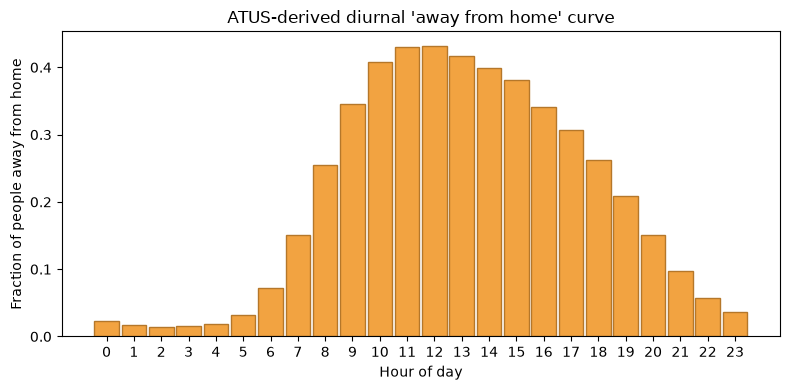

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(hours, frac_away_hour, width=0.9, color="#f2a341", edgecolor="#b5772a")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Fraction of people away from home")
ax.set_title("ATUS-derived diurnal 'away from home' curve")
ax.set_xticks(hours)
plt.tight_layout()
plt.show()


## 4. Turning the curve into a leave-probability

The sun clock now rings at a **fixed, constant rate** — the ring frequency
itself carries no information from ATUS. What ATUS informs is *how likely an
agent is to actually leave* when the clock rings: we normalize
`frac_away_hour` to a 0–1 intensity (1.0 at the empirical peak hour) and
scale it by a tunable ceiling probability, `BASE_LEAVE_PROB`.


In [6]:
RING_INTERVAL_HOURS = 2.0     # the clock rings every 5 hours on average, always
BASE_LEAVE_PROB = 0.5         # probability of leaving at the peak hour, when polled

leave_intensity_hourly = frac_away_hour / frac_away_hour.max()  # 0 to 1, peak hour = 1
leave_prob_hourly = BASE_LEAVE_PROB * leave_intensity_hourly

def leave_prob_at(t_hours):
    """Probability an at-home agent leaves, given the clock just rang at t_hours."""
    h = int(np.floor(t_hours)) % 24
    return leave_prob_hourly[h]

print(f"Leave probability ranges from {leave_prob_hourly.min():.3f} "
      f"(hour {leave_prob_hourly.argmin()}) to {leave_prob_hourly.max():.3f} "
      f"(hour {leave_prob_hourly.argmax()})")

for r in range(0, len(leave_prob_hourly)):
    print(f"Leave probability at hour {r}: {leave_prob_hourly[r]}")


Leave probability ranges from 0.016 (hour 2) to 0.500 (hour 12)
Leave probability at hour 0: 0.02613632663659811
Leave probability at hour 1: 0.019297677019285437
Leave probability at hour 2: 0.015850093327912936
Leave probability at hour 3: 0.017219079201718408
Leave probability at hour 4: 0.022052730413938404
Leave probability at hour 5: 0.037598547375275994
Leave probability at hour 6: 0.08391036621104082
Leave probability at hour 7: 0.17434973720798744
Leave probability at hour 8: 0.2952659936677701
Leave probability at hour 9: 0.4004709750640461
Leave probability at hour 10: 0.4723363753710514
Leave probability at hour 11: 0.4983580238190999
Leave probability at hour 12: 0.5
Leave probability at hour 13: 0.4825668909556982
Leave probability at hour 14: 0.4623208854875119
Leave probability at hour 15: 0.44106586828045724
Leave probability at hour 16: 0.3946043037318085
Leave probability at hour 17: 0.354708412728102
Leave probability at hour 18: 0.30339028780388755
Leave probabilit

## 5. Sampling ring times: constant-rate Poisson process

Since the ring rate no longer depends on the time of day, this is just a
**homogeneous** Poisson process — gaps between rings are i.i.d.
`Exponential(rate)` draws, with `rate = 1 / RING_INTERVAL_HOURS`. No
thinning/rejection step is needed here, because there's nothing to thin
against: every candidate gap *is* a real ring.


In [29]:
def sample_homogeneous_poisson(rate_per_hour, T_hours, rng):
    """Return an array of ring times (hours) in [0, T_hours)."""
    t = 0.0
    rings = []
    while True:
        t += rng.exponential(1.0 / rate_per_hour)
        if t >= T_hours:
            break
        rings.append(t)
    return np.array(rings)


ring_rate = 1.0 / RING_INTERVAL_HOURS
sun_clock_rings_today = sample_homogeneous_poisson(ring_rate, 24.0, rng)
print(f"{len(sun_clock_rings_today)} rings today, at hours:")
print(np.round(sun_clock_rings_today, 2))


9 rings today, at hours:
[ 2.45  2.6   3.12  5.83 10.19 11.26 15.76 17.94 22.34]


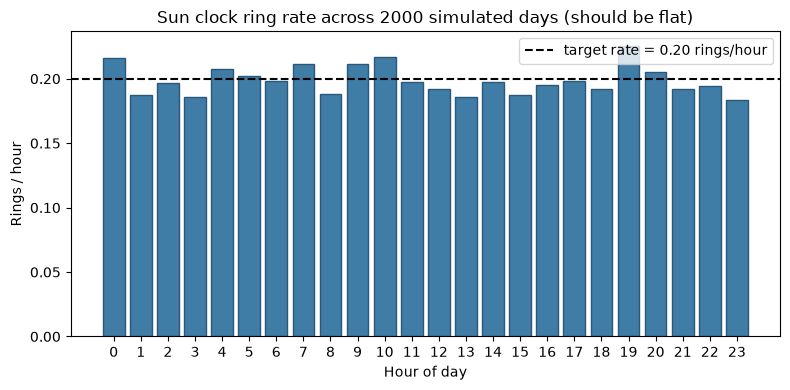

In [21]:
# Sanity check: over many simulated days, rings should land ~uniformly
# across hours (constant rate), while the *leave probability* -- not shown
# here -- is what varies by hour. This just confirms the ring generator
# itself is behaving as a plain constant-rate process.
N_DAYS = 2000
all_rings = np.concatenate([
    sample_homogeneous_poisson(ring_rate, 24.0, rng) for _ in range(N_DAYS)
])

hist, edges = np.histogram(all_rings, bins=24, range=(0, 24))
empirical_rings_per_hour = hist / N_DAYS

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(hours, empirical_rings_per_hour, color="#3f7ca6", edgecolor="#2c5878")
ax.axhline(ring_rate, color="black", linestyle="--",
           label=f"target rate = {ring_rate:.2f} rings/hour")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Rings / hour")
ax.set_title(f"Sun clock ring rate across {N_DAYS} simulated days (should be flat)")
ax.set_xticks(hours)
ax.legend()
plt.tight_layout()
plt.show()


## 6. Wiring the sun clock into the epidemic model

Two common ways to use this:

**A. Shared global clock.** One constant-rate clock drives a "tick" for the
whole simulation. Every time it rings, each agent currently at home
independently rolls the dice on leaving, using `leave_prob_at(t)` (possibly
further adjusted per-agent for health state, household role, policy, etc.).

**B. Per-agent clock.** Every agent samples its own constant-rate ring
sequence for the day (optionally with an agent-specific `RING_INTERVAL_HOURS`
or `BASE_LEAVE_PROB` — e.g. essential workers get a higher ceiling
probability, retirees a lower one).

A minimal sketch of (A):


In [30]:
def simulate_agent_day(agent_home_state, leave_prob_at, rings, rng):
    """
    agent_home_state: bool, True if currently at home
    leave_prob_at: function mapping a ring time -> probability of leaving
                    (this is where individual heterogeneity / health state /
                    lockdown policy etc. can be layered on top of the ATUS curve)
    Returns: list of (time, event) where event in {"ring", "left_home"}
    """
    log = []
    at_home = agent_home_state
    for t in rings:
        log.append((t, "ring"))
        if at_home and rng.random() < leave_prob_at(t):
            at_home = False
            log.append((t, "left_home"))
    return log


# example: one agent, over one simulated day, using the shared clock above
example_rings = sample_homogeneous_poisson(ring_rate, 24.0, rng)
example_log = simulate_agent_day(
    agent_home_state=True, leave_prob_at=leave_prob_at,
    rings=example_rings, rng=rng,
)
example_log


[(np.float64(0.23346318901675814), 'ring'),
 (np.float64(1.1467621223580886), 'ring'),
 (np.float64(1.6685117506481613), 'ring'),
 (np.float64(3.6477665747496664), 'ring'),
 (np.float64(7.511673540195911), 'ring'),
 (np.float64(7.7730321666699895), 'ring'),
 (np.float64(11.149994998715906), 'ring'),
 (np.float64(11.149994998715906), 'left_home'),
 (np.float64(15.090655885189705), 'ring'),
 (np.float64(16.296436295951562), 'ring'),
 (np.float64(16.719427077187905), 'ring'),
 (np.float64(16.88239032269841), 'ring'),
 (np.float64(17.444913111787063), 'ring'),
 (np.float64(17.687378560948215), 'ring'),
 (np.float64(18.463705125903562), 'ring'),
 (np.float64(19.832058640403908), 'ring'),
 (np.float64(21.542776262925372), 'ring')]

## 7. Exporting the leave-probability curve for use outside this notebook

Save the hourly probability table so your main simulation code (which might
not be Python/pandas) can just read a CSV lookup table instead of
re-deriving it from ATUS each time.


In [31]:
leave_prob_table = pd.DataFrame({
    "hour": hours,
    "fraction_away": frac_away_hour,
    "leave_intensity": leave_intensity_hourly,
    "leave_probability": leave_prob_hourly,
})
leave_prob_table.to_csv("sun_clock_leave_probability.csv", index=False)
leave_prob_table


,hour,fraction_away,leave_intensity,leave_probability
0,0,0.022577,0.052273,0.026136
1,1,0.016669,0.038595,0.019298
2,2,0.013691,0.031700,0.015850
3,3,0.014874,0.034438,0.017219
4,4,0.019049,0.044105,0.022053
5,5,0.032478,0.075197,0.037599
6,6,0.072482,0.167821,0.083910
7,7,0.150604,0.348699,0.174350
8,8,0.255051,0.590532,0.295266
9,9,0.345928,0.800942,0.400471


## Notes / things to double-check against your real extract

- **`Household_ID` as the diary-day key**: the loader treats this column as
  the unique respondent-day identifier, the same role `TUCASEID` plays in
  standard ATUS. If `Household_ID` can have more than one respondent per
  household in your extract, activities from different people in the same
  household would get merged as if they were one person's day, corrupting
  the sweep-line accumulation — worth confirming this is effectively a
  per-respondent-day key.
- **Weekday vs. weekend**: this notebook pools all diary days together. If
  your model distinguishes weekday/weekend "suns," split `activity_df` by a
  day-of-week column (`TUDIARYDAY`, usually on the Respondent file — merge
  it in on the case ID) and repeat Sections 3–4 per subgroup.
- **No survey weights**: with `weight_col: None`, the notebook uses
  unweighted counts (each activity/respondent counted equally). Fine for
  shaping the leave-probability curve if your extract is already a
  reasonably representative sample; just know the resulting curve isn't
  population-weighted.
- **`RING_INTERVAL_HOURS` and `BASE_LEAVE_PROB` are your free parameters**:
  the ring rate no longer comes from ATUS at all now, and `BASE_LEAVE_PROB`
  just sets the ceiling probability at the busiest hour. Consider
  calibrating `BASE_LEAVE_PROB` against a target like "average agent should
  leave the house N times per day" rather than picking it arbitrarily.
- **Finer time resolution**: everything here bins to whole hours for
  simplicity; the same sweep-line code works unchanged at 30- or 15-minute
  resolution by adjusting the binning loop in Section 3.
